# 🔧 Notebook 3 — Data Preprocessing & Feature Engineering

## Coal Demand Forecasting — CRISP-ML(Q) Framework

**Objective:** Clean the raw data and engineer features that improve model accuracy.

### What this notebook does:
1. **Forward-fill** missing values (time-series appropriate)
2. **Cap outliers** at IQR bounds
3. **Calendar features** — month, quarter, day_of_week
4. **Lag features** — 1, 7, 30-day lags of coal consumption
5. **Rolling features** — 7-day and 30-day rolling mean & std
6. **Interaction features** — temperature × coal price
7. **Train/Val/Test split** — 70/15/15, time-ordered (no shuffle)
8. **MinMax scaling** — Fit on train, transform all splits

---

## 3.1 Setup & Load Raw Data

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Enable inline plotting with high-quality defaults
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Load configuration constants ────────────────────────────────────────────
from src.config import (
    RAW_DATA_FILE, TRAIN_RATIO, VAL_RATIO, TEST_RATIO,
    LAG_FEATURES, ROLLING_WINDOWS, IQR_MULTIPLIER,
    PROCESSED_TRAIN_FILE, PROCESSED_VAL_FILE, PROCESSED_TEST_FILE,
    REPORTS_DIR
)
os.makedirs(os.path.dirname(PROCESSED_TRAIN_FILE), exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# ── Load raw data ────────────────────────────────────────────────────────────
df = pd.read_csv(RAW_DATA_FILE)
print(f"Raw data shape: {df.shape}")
print(f"\nMissing values before preprocessing:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Raw data shape: (1096, 8)

Missing values before preprocessing:
power_generation_mw        10
coal_consumption_tonnes    10
temperature_c              10
coal_price_inr             10
inventory_level_tonnes     10

Total missing: 50


## 3.2 Step 1 — Forward-Fill Missing Values

For time-series data, **forward-fill** (propagate last valid value) is more appropriate than mean/median imputation because it preserves temporal patterns. We also apply **back-fill** for any NaN at the very start.

In [2]:
# ── Forward-fill then back-fill missing values ───────────────────────────────
# For time-series: ffill propagates the last valid observation forward,
# then bfill handles any leading NaNs at the very start of the series.
total_fixed = 0
for col in df.columns:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        df[col] = df[col].ffill().bfill()
        print(f"  ✓ {col}: {missing_count} missing values filled")
        total_fixed += missing_count

print(f"\nTotal missing values fixed: {total_fixed}")
print(f"Remaining NaN: {df.isnull().sum().sum()}")

  ✓ power_generation_mw: 10 missing values filled
  ✓ coal_consumption_tonnes: 10 missing values filled
  ✓ temperature_c: 10 missing values filled
  ✓ coal_price_inr: 10 missing values filled
  ✓ inventory_level_tonnes: 10 missing values filled

Total missing values fixed: 50
Remaining NaN: 0


## 3.3 Step 2 — Cap Outliers at IQR Bounds

Using the **IQR method** (multiplier = 1.5):
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- Values beyond these bounds are clipped

  ✓ power_generation_mw: 40 outliers capped (bounds: [374.76, 690.16])
  ✓ coal_consumption_tonnes: 35 outliers capped (bounds: [165.43, 312.40])

Total outliers capped: 75


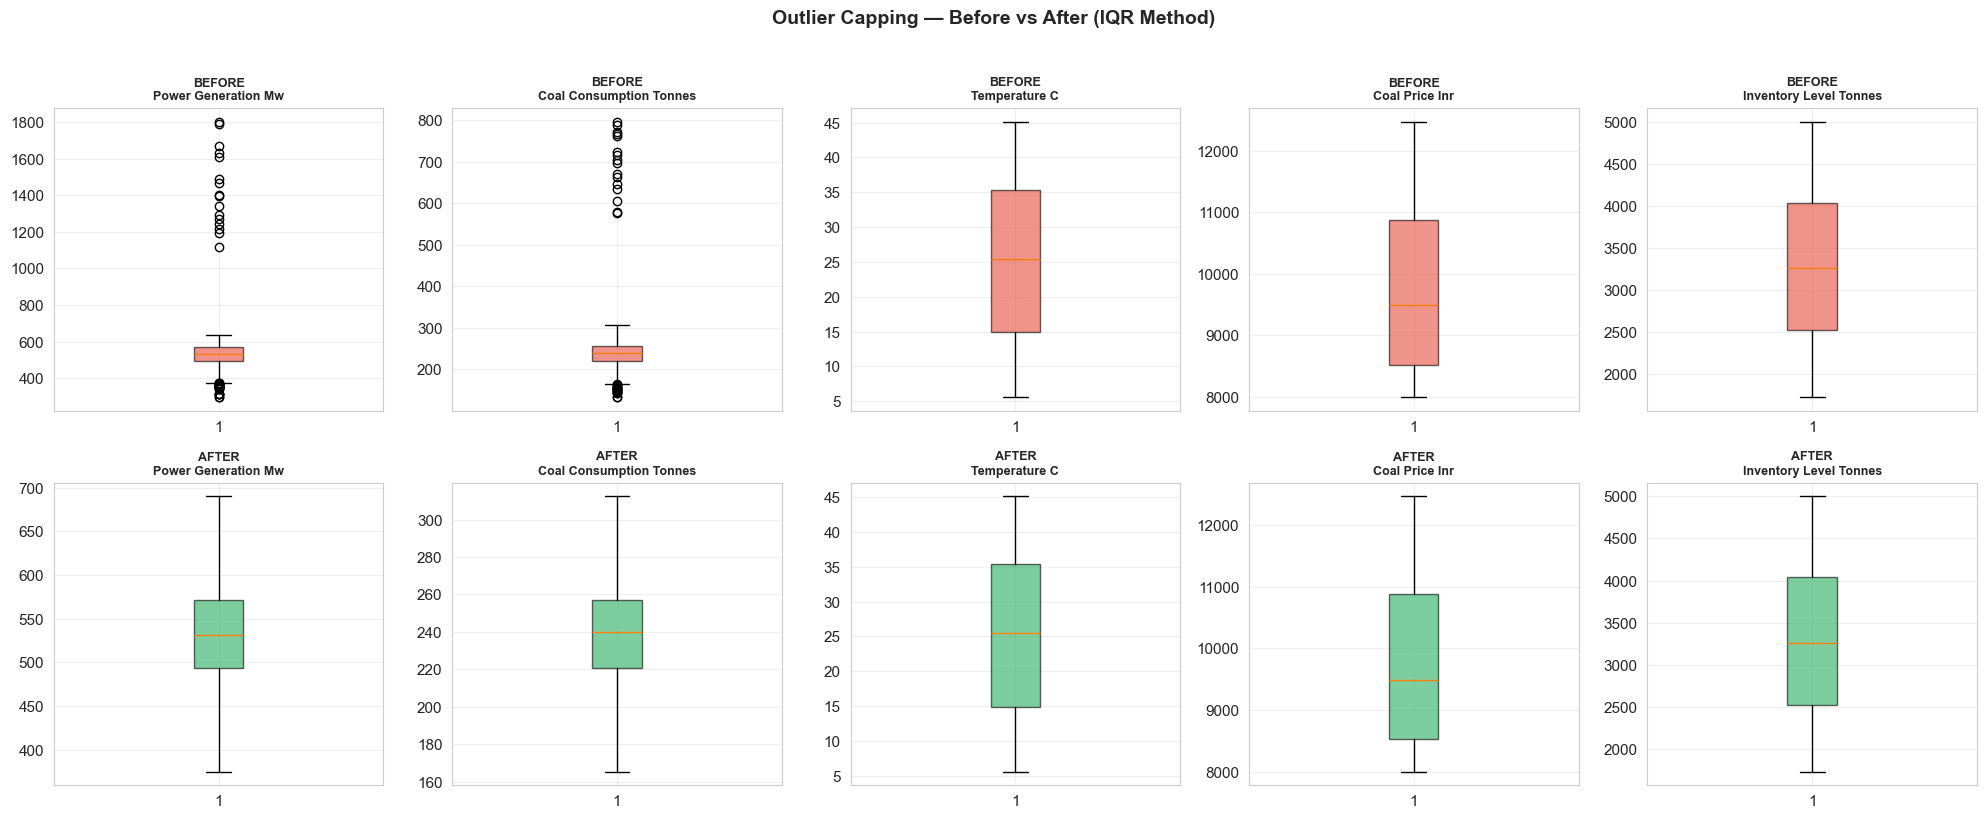

In [3]:
# ── Cap outliers at IQR bounds ────────────────────────────────────────────────
# Save a copy before capping for before/after comparison visualization
numeric_cols_to_cap = ['power_generation_mw', 'coal_consumption_tonnes',
                       'temperature_c', 'coal_price_inr', 'inventory_level_tonnes']
df_before = df[numeric_cols_to_cap].copy()  # snapshot for visualization

total_capped = 0
for col in numeric_cols_to_cap:
    if col not in df.columns:
        continue
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - IQR_MULTIPLIER * iqr
    upper = q3 + IQR_MULTIPLIER * iqr
    capped = int(((df[col] < lower) | (df[col] > upper)).sum())
    df[col] = df[col].clip(lower=lower, upper=upper)
    if capped > 0:
        print(f"  ✓ {col}: {capped} outliers capped (bounds: [{lower:.2f}, {upper:.2f}])")
        total_capped += capped

print(f"\nTotal outliers capped: {total_capped}")

# ── Before/After Outlier Capping Visualization ───────────────────────────────
fig, axes = plt.subplots(2, len(numeric_cols_to_cap), figsize=(4*len(numeric_cols_to_cap), 8))
for i, col in enumerate(numeric_cols_to_cap):
    axes[0, i].boxplot(df_before[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#E74C3C', alpha=0.6))
    axes[0, i].set_title(f'BEFORE\n{col.replace("_"," ").title()}', fontsize=9, fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].boxplot(df[col].dropna(), patch_artist=True,
                       boxprops=dict(facecolor='#27AE60', alpha=0.6))
    axes[1, i].set_title(f'AFTER\n{col.replace("_"," ").title()}', fontsize=9, fontweight='bold')
    axes[1, i].grid(True, alpha=0.3)

plt.suptitle('Outlier Capping — Before vs After (IQR Method)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'outlier_capping.png'), dpi=150, bbox_inches='tight')
plt.show()
del df_before  # free memory

## 3.4 Step 3 — Calendar Features

Adding temporal features that capture periodic patterns:
- **month** (1-12) — Captures seasonal demand patterns
- **quarter** (1-4) — Quarterly business cycles
- **day_of_week** (0-6, Mon=0) — Weekday/weekend demand differences

In [4]:
# ── Calendar features — capture periodic patterns ────────────────────────────
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month        # 1-12: seasonal demand
df['quarter'] = df['date'].dt.quarter    # 1-4: quarterly business cycles
df['day_of_week'] = df['date'].dt.dayofweek  # 0-6: weekday effects
df['day_of_year'] = df['date'].dt.dayofyear  # 1-365: fine-grained seasonality
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)  # 1-52

print('Calendar features added: month, quarter, day_of_week, day_of_year, week_of_year')
print(f'\nMonth distribution:')
print(df['month'].value_counts().sort_index().to_string())

Calendar features added: month, quarter, day_of_week, day_of_year, week_of_year

Month distribution:
month
1     93
2     85
3     93
4     90
5     93
6     90
7     93
8     93
9     90
10    93
11    90
12    93


## 3.5 Step 4 — Lag Features

Lag features capture **autoregressive** behavior — today's consumption depends on recent past values:
- **lag_1** — Yesterday's consumption (strongest predictor)
- **lag_7** — Same day last week (weekly pattern)
- **lag_30** — Same day last month (monthly pattern)

In [5]:
# ── Lag features — autoregressive predictors ──────────────────────────────────
# Each lag_N feature represents the coal consumption N days ago.
# This captures temporal dependencies: today's usage depends on recent history.
target = 'coal_consumption_tonnes'
for lag in LAG_FEATURES:
    col_name = f'lag_{lag}'
    df[col_name] = df[target].shift(lag)  # shift the target column by 'lag' days
    print(f"  ✓ Added {col_name} (shift by {lag} days)")

print(f"\nLag features sample (last 5 rows):")
display(df[['date', target, 'lag_1', 'lag_7', 'lag_30']].tail())

  ✓ Added lag_1 (shift by 1 days)
  ✓ Added lag_2 (shift by 2 days)
  ✓ Added lag_3 (shift by 3 days)
  ✓ Added lag_7 (shift by 7 days)
  ✓ Added lag_14 (shift by 14 days)
  ✓ Added lag_30 (shift by 30 days)

Lag features sample (last 5 rows):


,date,coal_consumption_tonnes,lag_1,lag_7,lag_30
1091,2024-12-27,273.86,256.69,247.53,251.57
1092,2024-12-28,214.91,273.86,228.58,246.83
1093,2024-12-29,219.16,214.91,222.30,254.53
1094,2024-12-30,255.07,219.16,277.58,215.44
1095,2024-12-31,254.47,255.07,265.09,213.92


## 3.6 Step 5 — Rolling Features

Rolling statistics smooth out daily noise and capture **moving trends**:
- **rolling_mean_7** — 7-day moving average
- **rolling_mean_30** — 30-day moving average
- **rolling_std_7** — 7-day rolling standard deviation (captures volatility)

In [6]:
# ── Rolling features — smoothed trend indicators ─────────────────────────────
# Rolling mean captures the moving trend (smoothes out daily noise).
# Rolling std captures recent volatility (how much the signal is fluctuating).
# Rolling min/max capture the range.
# EWM (exponential weighted mean) gives more weight to recent observations.
# shift(1) prevents data leakage — we use PAST data only.
for window in ROLLING_WINDOWS:
    mean_col = f'rolling_mean_{window}'
    df[mean_col] = df[target].shift(1).rolling(window=window, min_periods=1).mean()
    print(f"  ✓ Added {mean_col}")

df['rolling_std_7'] = df[target].shift(1).rolling(window=7, min_periods=1).std()
print("  ✓ Added rolling_std_7")

# Additional rolling features for better signal capture
df['rolling_min_7'] = df[target].shift(1).rolling(window=7, min_periods=1).min()
print("  ✓ Added rolling_min_7")
df['rolling_max_7'] = df[target].shift(1).rolling(window=7, min_periods=1).max()
print("  ✓ Added rolling_max_7")

# Exponential weighted mean — gives more weight to recent days
df['ewm_7'] = df[target].shift(1).ewm(span=7, adjust=False).mean()
print("  ✓ Added ewm_7 (exponential weighted mean)")

# Power generation lag — strong correlation with target
df['power_lag_1'] = df['power_generation_mw'].shift(1)
print("  ✓ Added power_lag_1")

print(f"\nRolling features sample (last 3 rows):")
display(df[['rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'ewm_7']].tail(3))

  ✓ Added rolling_mean_7
  ✓ Added rolling_mean_14
  ✓ Added rolling_mean_30
  ✓ Added rolling_std_7
  ✓ Added rolling_min_7
  ✓ Added rolling_max_7
  ✓ Added ewm_7 (exponential weighted mean)
  ✓ Added power_lag_1

Rolling features sample (last 3 rows):


,rolling_mean_7,rolling_std_7,rolling_min_7,rolling_max_7,ewm_7
1093,240.858571,37.758872,175.58,277.58,240.905081
1094,240.410000,38.033743,175.58,277.58,235.468811
1095,237.194286,35.214378,175.58,273.86,240.369108


## 3.7 Step 6 — Interaction Features

Interaction features capture **non-linear relationships** between variables:
- **temp_coal_interaction** = temperature × coal_price — Captures how price sensitivity changes with temperature

In [7]:
# ── Interaction & polynomial features — captures non-linear relationships ─────
# When temperature is high AND coal price is high, the dynamic is different.
df['temp_coal_interaction'] = df['temperature_c'] * df['coal_price_inr']
print("  ✓ Added temp_coal_interaction = temperature × coal_price")

# Temperature squared — captures non-linear heat effect on demand
df['temp_squared'] = df['temperature_c'] ** 2
print("  ✓ Added temp_squared")

# Power × temperature — high power + high temp → peak coal usage
df['power_temp_interaction'] = df['power_generation_mw'] * df['temperature_c']
print("  ✓ Added power_temp_interaction")

# ── Drop NaN rows created by lag/rolling lookback ─────────────────────────────
initial_len = len(df)
df = df.dropna().reset_index(drop=True)
print(f"\nDropped {initial_len - len(df)} rows with NaN from feature engineering")
print(f"Final processed shape: {df.shape}")
print(f"Final columns ({len(df.columns)}): {list(df.columns)}")

  ✓ Added temp_coal_interaction = temperature × coal_price
  ✓ Added temp_squared
  ✓ Added power_temp_interaction

Dropped 30 rows with NaN from feature engineering
Final processed shape: (1066, 30)
Final columns (30): ['date', 'power_generation_mw', 'coal_consumption_tonnes', 'temperature_c', 'coal_price_inr', 'inventory_level_tonnes', 'is_holiday', 'is_weekend', 'month', 'quarter', 'day_of_week', 'day_of_year', 'week_of_year', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'ewm_7', 'power_lag_1', 'temp_coal_interaction', 'temp_squared', 'power_temp_interaction']


## 3.8 Step 7 — Train / Validation / Test Split

**Time-ordered split** (no shuffling to avoid data leakage):
- **Train: 70%** — Model learns patterns
- **Validation: 15%** — Hyperparameter tuning
- **Test: 15%** — Final unbiased evaluation

Split      Shape           Date Range
────────────────────────────────────────────────────────────
Train      (746, 30)       2022-01-31 → 2024-02-15
Val        (160, 30)       2024-02-16 → 2024-07-24
Test       (160, 30)       2024-07-25 → 2024-12-31


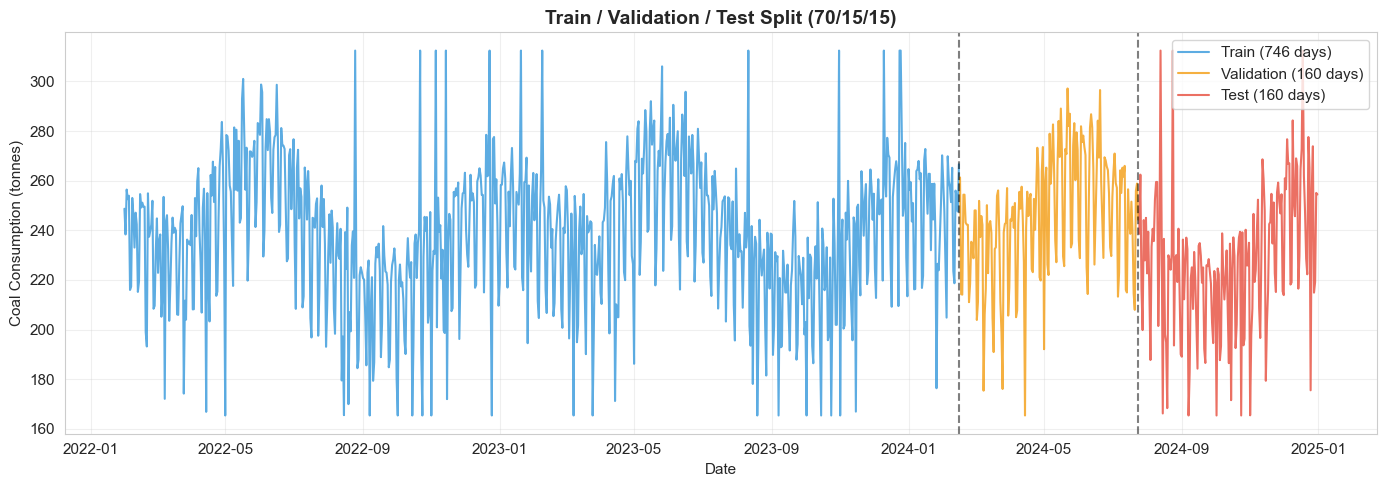

In [8]:
# ── Time-ordered split (70/15/15) ─────────────────────────────────────────────
# IMPORTANT: data is sorted chronologically, NO shuffling.
# Shuffling would cause data leakage (future data in training set).
from sklearn.preprocessing import MinMaxScaler

df = df.sort_values('date').reset_index(drop=True)
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"{'Split':<10} {'Shape':<15} {'Date Range'}")
print(f"{'─'*60}")
print(f"{'Train':<10} {str(train_df.shape):<15} {train_df['date'].iloc[0].date()} → {train_df['date'].iloc[-1].date()}")
print(f"{'Val':<10} {str(val_df.shape):<15} {val_df['date'].iloc[0].date()} → {val_df['date'].iloc[-1].date()}")
print(f"{'Test':<10} {str(test_df.shape):<15} {test_df['date'].iloc[0].date()} → {test_df['date'].iloc[-1].date()}")

# ── Visualize the train/val/test split on the time series ────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_df['date'], train_df[target], color='#3498DB',
        label=f'Train ({len(train_df)} days)', alpha=0.8)
ax.plot(val_df['date'], val_df[target], color='#F39C12',
        label=f'Validation ({len(val_df)} days)', alpha=0.8)
ax.plot(test_df['date'], test_df[target], color='#E74C3C',
        label=f'Test ({len(test_df)} days)', alpha=0.8)
ax.axvline(x=train_df['date'].iloc[-1], color='black', linestyle='--', alpha=0.5)
ax.axvline(x=val_df['date'].iloc[-1], color='black', linestyle='--', alpha=0.5)
ax.set_title('Train / Validation / Test Split (70/15/15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Coal Consumption (tonnes)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'train_val_test_split.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.9 Step 8 — MinMax Scaling

Scale all features to [0, 1] range using **MinMaxScaler**:
- Fitted on **training data only** (prevents data leakage)
- Applied to train, val, and test sets

In [9]:
# ── MinMaxScaler — scale features to [0, 1] range ─────────────────────────────
# CRITICAL: Scaler is fit on TRAINING data only.
# If we fit on all data, information about val/test distributions leaks into
# the scaler parameters, causing overly optimistic evaluation.
feature_cols = [c for c in df.columns if c not in ['date', 'coal_consumption_tonnes']]
scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])  # fit ONLY on train

train_df[feature_cols] = scaler.transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

print(f"Scaled {len(feature_cols)} features to [0, 1]:")
for col in feature_cols:
    print(f"  {col}: train range [{train_df[col].min():.3f}, {train_df[col].max():.3f}]")

print(f"\n✅ Preprocessing complete!")
print(f"   Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
print(f"   Feature columns: {len(feature_cols)}")
print(f"   Target: coal_consumption_tonnes (NOT scaled)")

Scaled 28 features to [0, 1]:
  power_generation_mw: train range [0.000, 1.000]
  temperature_c: train range [0.000, 1.000]
  coal_price_inr: train range [0.000, 1.000]
  inventory_level_tonnes: train range [0.000, 1.000]
  is_holiday: train range [0.000, 1.000]
  is_weekend: train range [0.000, 1.000]
  month: train range [0.000, 1.000]
  quarter: train range [0.000, 1.000]
  day_of_week: train range [0.000, 1.000]
  day_of_year: train range [0.000, 1.000]
  week_of_year: train range [0.000, 1.000]
  lag_1: train range [0.000, 1.000]
  lag_2: train range [0.000, 1.000]
  lag_3: train range [0.000, 1.000]
  lag_7: train range [0.000, 1.000]
  lag_14: train range [0.000, 1.000]
  lag_30: train range [0.000, 1.000]
  rolling_mean_7: train range [0.000, 1.000]
  rolling_mean_14: train range [0.000, 1.000]
  rolling_mean_30: train range [0.000, 1.000]
  rolling_std_7: train range [0.000, 1.000]
  rolling_min_7: train range [0.000, 1.000]
  rolling_max_7: train range [0.000, 1.000]
  ewm_7:

## 3.10 Processed Data Preview

Training data sample (first 5 rows):


,date,power_generation_mw,coal_consumption_tonnes,temperature_c,coal_price_inr,inventory_level_tonnes,is_holiday,is_weekend,month,quarter,...,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_min_7,rolling_max_7,ewm_7,power_lag_1,temp_coal_interaction,temp_squared,power_temp_interaction
0,2022-01-31,0.638499,248.70,0.158568,0.128411,0.647714,0.0,0.0,0.000000,0.0,...,0.578216,0.572900,0.406689,0.273597,0.364913,0.402722,0.335994,0.139030,0.056476,0.175814
1,2022-02-01,0.583838,238.35,0.135550,0.138762,0.570529,0.0,0.0,0.090909,0.0,...,0.582118,0.587045,0.397609,0.273597,0.364913,0.451698,0.638499,0.120155,0.045891,0.146854
2,2022-02-02,0.594681,256.42,0.020460,0.137297,0.487492,0.0,0.0,0.090909,0.0,...,0.558280,0.594245,0.393915,0.273597,0.364913,0.457895,0.583838,0.020181,0.005125,0.045694
3,2022-02-03,0.593857,252.54,0.069054,0.144512,0.405712,0.0,0.0,0.090909,0.0,...,0.553705,0.594929,0.210814,0.580832,0.364913,0.515855,0.594681,0.062879,0.019865,0.088977
4,2022-02-04,0.657332,253.94,0.074169,0.106797,0.323478,0.0,0.0,0.090909,0.0,...,0.544298,0.590600,0.194895,0.580832,0.358380,0.547877,0.593857,0.064400,0.021627,0.100774



Target statistics across splits:
  Train — mean: 238.50, std: 28.93
  Val   — mean: 245.60, std: 25.19
  Test  — mean: 227.61, std: 28.60


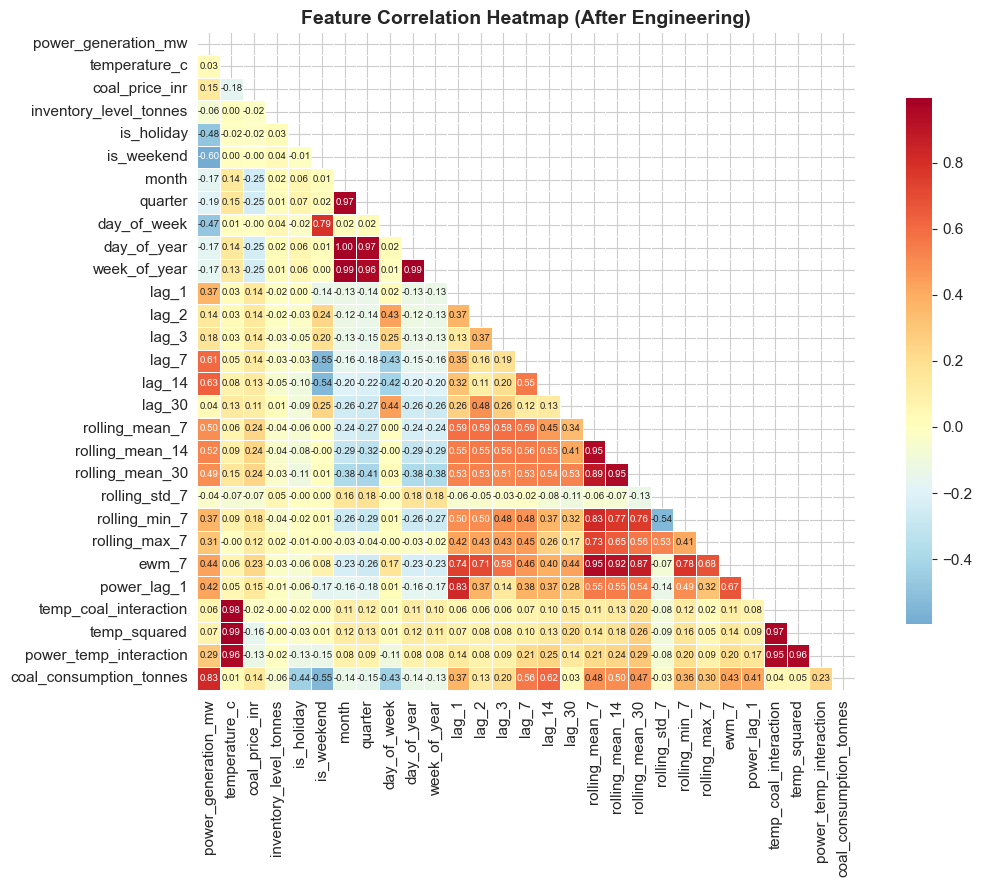


✅ Saved preprocessed data:
   Train → /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/data/processed/train.csv ((746, 30))
   Val   → /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/data/processed/val.csv ((160, 30))
   Test  → /Users/palasudeepkumar/Desktop/Foundation_Project/coal-demand-forecasting/data/processed/test.csv ((160, 30))


In [10]:
# ── Preview processed data ────────────────────────────────────────────────────
print("Training data sample (first 5 rows):")
display(train_df.head())

print(f"\nTarget statistics across splits:")
print(f"  Train — mean: {train_df[target].mean():.2f}, std: {train_df[target].std():.2f}")
print(f"  Val   — mean: {val_df[target].mean():.2f}, std: {val_df[target].std():.2f}")
print(f"  Test  — mean: {test_df[target].mean():.2f}, std: {test_df[target].std():.2f}")

# ── Feature correlation heatmap (post-engineering) ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))
corr = train_df[feature_cols + [target]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
ax.set_title('Feature Correlation Heatmap (After Engineering)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'feature_correlation_post_engineering.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── Save preprocessed splits to CSV ──────────────────────────────────────────
# These CSVs are consumed by notebooks 04, 05, and 06.
train_df.to_csv(PROCESSED_TRAIN_FILE, index=False)
val_df.to_csv(PROCESSED_VAL_FILE, index=False)
test_df.to_csv(PROCESSED_TEST_FILE, index=False)

print(f"\n✅ Saved preprocessed data:")
print(f"   Train → {PROCESSED_TRAIN_FILE} ({train_df.shape})")
print(f"   Val   → {PROCESSED_VAL_FILE} ({val_df.shape})")
print(f"   Test  → {PROCESSED_TEST_FILE} ({test_df.shape})")